In [ ]:
import os
import json
import gymnasium as gym
import numpy as np
import torch

from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import SubprocVecEnv, VecNormalize
from stable_baselines3.common.callbacks import BaseCallback, EvalCallback

# ===============================
# CONFIG
# ===============================
ENV_ID = "BipedalWalkerHardcore-v3"
SEED = 42
N_ENVS = 8
TOTAL_TIMESTEPS = 20_000_000

LOG_DIR = "./ppo_hardcore_stable/"
MODEL_DIR = os.path.join(LOG_DIR, "models")
os.makedirs(MODEL_DIR, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

# ===============================
# HELPERS
# ===============================

class SyncEnvStatsCallback(BaseCallback):
    def __init__(self, eval_env, sync_freq=100_000):
        super().__init__(verbose=0)
        self.eval_env = eval_env
        self.sync_freq = sync_freq

    def _on_step(self) -> bool:
        if self.n_calls % self.sync_freq == 0:
            self.eval_env.obs_rms = self.training_env.obs_rms
        return True

def make_env(rank):
    def _init():
        env = gym.make(ENV_ID)
        env.reset(seed=SEED + rank)
        return env
    return _init

def linear_schedule(initial_value: float, final_value: float = 0.0):
    def func(progress_remaining: float) -> float:
        return progress_remaining * initial_value + final_value * (1 - progress_remaining)
    return func

l_r = linear_schedule(5e-4, 1e-5)

# ===============================
# ENVIRONMENTS
# ===============================
train_env = SubprocVecEnv([make_env(i) for i in range(N_ENVS)])
train_env = VecNormalize(
    train_env,
    norm_obs=True,
    norm_reward=True,
    gamma=0.995,
    clip_obs=10.0
)

eval_env = SubprocVecEnv([make_env(1000 + i) for i in range(5)])
eval_env = VecNormalize(
    eval_env,
    norm_obs=True,
    norm_reward=False,
    training=False
)

# ===============================
# CALLBACKS
# ===============================

eval_callback = EvalCallback(
    eval_env,
    best_model_save_path=os.path.join(MODEL_DIR, "best"),
    log_path=os.path.join(LOG_DIR, "eval"),
    eval_freq=max(100_000 // N_ENVS, 1),
    n_eval_episodes=5,
    deterministic=True,
    verbose=0,
)

sync_stats_callback = SyncEnvStatsCallback(eval_env, 100_000)

# ===============================
# MODEL
# ===============================
model = PPO(
    policy="MlpPolicy",
    env=train_env,
    device=DEVICE,
    seed=SEED,

    # Architecture
    policy_kwargs=dict(
        net_arch=dict(pi=[256, 256], vf=[256, 256]), #next model try [400, 300]
        activation_fn=torch.nn.Tanh,
        ortho_init=True, #i should try Xavier later too
    ),

    # PPO core
    learning_rate=l_r,
    n_steps=2048,
    batch_size=1024,
    n_epochs=8,
    gamma=0.995,    
    gae_lambda=0.95,

    # Stability fixes
    clip_range=0.2,
    ent_coef=0.01,
    vf_coef=0.5,
    max_grad_norm=0.5,
    target_kl=0.02,
    use_sde=True,
    sde_sample_freq=8, #next model try -1

    verbose=0,
)

# ===============================
# TRAIN
# ===============================
model.learn(
    total_timesteps=TOTAL_TIMESTEPS,
    callback=[sync_stats_callback, eval_callback],
    progress_bar=True,
)

# ===============================
# SAVE FINAL
# ===============================
model.save(os.path.join(MODEL_DIR, "final_model"))
train_env.save(os.path.join(MODEL_DIR, "vec_normalize.pkl"))

metadata = {
    "env": ENV_ID,
    "total_timesteps": TOTAL_TIMESTEPS,
    "seed": SEED,
    "n_envs": N_ENVS,
    "device": DEVICE,
}

with open(os.path.join(LOG_DIR, "run_info.json"), "w") as f:
    json.dump(metadata, f, indent=2)

train_env.close()
eval_env.close()

print("✅ Training complete.")


Using device: cpu


Output()

d:\Users\draar\AppData\Local\Programs\Python\Python311\Lib\site-packages\stable_baselines3\common\evaluation.py:70:
UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting 
modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first
with ``Monitor`` wrapper.
  warnings.warn(

Eval num_timesteps=100000, episode_reward=-145.25 +/- 11.07

Episode length: 2000.00 +/- 0.00

...

Eval num_timesteps=59900000, episode_reward=8.51 +/- 70.62

Episode length: 1200.20 +/- 537.25

Eval num_timesteps=60000000, episode_reward=-69.54 +/- 52.34

Episode length: 919.80 +/- 720.62

✅ Training complete.


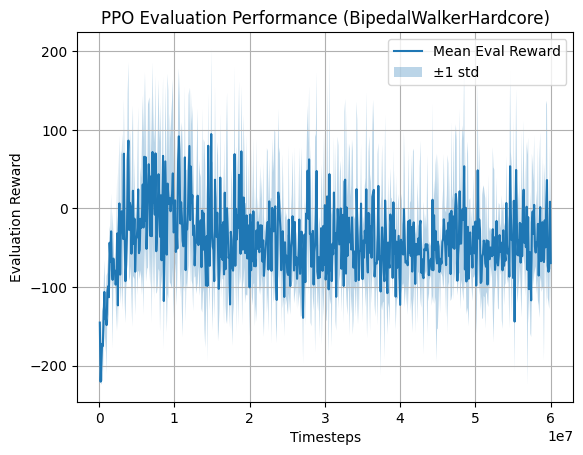

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os

EVAL_PATH = "./ppo_hardcore_stable/eval/evaluations.npz"

data = np.load(EVAL_PATH)

timesteps = data["timesteps"]                 # shape (N,)
results = data["results"]                     # shape (N, n_eval_episodes)

mean_rewards = results.mean(axis=1)
std_rewards = results.std(axis=1)

plt.figure()
plt.plot(timesteps, mean_rewards, label="Mean Eval Reward")
plt.fill_between(
    timesteps,
    mean_rewards - std_rewards,
    mean_rewards + std_rewards,
    alpha=0.3,
    label="±1 std"
)

plt.xlabel("Timesteps")
plt.ylabel("Evaluation Reward")
plt.title("PPO Evaluation Performance (BipedalWalkerHardcore)")
plt.legend()
plt.grid(True)
plt.show()


In [9]:
import os
import gymnasium as gym
import imageio
import numpy as np
import torch

from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize

# ===============================
# CONFIG
# ===============================
ENV_ID = "BipedalWalkerHardcore-v3"
MODEL_DIR = "./ppo_hardcore_stable/models"
VECNORM_PATH = os.path.join(MODEL_DIR, "vec_normalize.pkl")
MODEL_PATH = os.path.join(MODEL_DIR, "best/best_model.zip")

OUTPUT_DIR = "./bestgifs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

SEED = 42
N_TRAIN_ENVS = 8
N_EVAL_ENVS = 5
MAX_STEPS = 2000
FPS = 30

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ===============================
# LOAD MODEL
# ===============================
model = PPO.load(MODEL_PATH, device=DEVICE)

# ===============================
# ENV FACTORY (single env)
# ===============================
def make_single_env(seed):
    def _init():
        env = gym.make(ENV_ID, render_mode="rgb_array")
        env.reset(seed=seed)
        return env
    return _init

# ===============================
# ROLLOUT + GIF
# ===============================
def record_env(seed, name):
    env = DummyVecEnv([make_single_env(seed)])
    env = VecNormalize.load(VECNORM_PATH, env)

    # IMPORTANT
    env.training = False
    env.norm_reward = False

    obs = env.reset()
    frames = []

    for step in range(MAX_STEPS):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, info = env.step(action)

        frame = env.envs[0].render()
        frames.append(frame)

        if done:
            break

    path = os.path.join(OUTPUT_DIR, f"{name}.gif")
    imageio.mimsave(path, frames, fps=FPS)

    env.close()
    print(f"Saved {path}")

# ===============================
# TRAINING ENVS
# ===============================
for i in range(N_TRAIN_ENVS):
    seed = SEED + i
    record_env(seed, f"train_env_{i}")

# ===============================
# EVAL ENVS
# ===============================
for i in range(N_EVAL_ENVS):
    seed = 1000 + SEED + i
    record_env(seed, f"eval_env_{i}")

print("✅ All GIFs created.")


d:\Users\draar\AppData\Local\Programs\Python\Python311\Lib\site-packages\imageio\plugins\pillow.py:409: DeprecationWarning: The keyword `fps` is no longer supported. Use `duration`(in ms) instead, e.g. `fps=50` == `duration=20` (1000 * 1/50).
  warnings.warn(


Saved ./bestgifs\train_env_0.gif
Saved ./bestgifs\train_env_1.gif
Saved ./bestgifs\train_env_2.gif
Saved ./bestgifs\train_env_3.gif
Saved ./bestgifs\train_env_4.gif
Saved ./bestgifs\train_env_5.gif
Saved ./bestgifs\train_env_6.gif
Saved ./bestgifs\train_env_7.gif
Saved ./bestgifs\eval_env_0.gif
Saved ./bestgifs\eval_env_1.gif
Saved ./bestgifs\eval_env_2.gif
Saved ./bestgifs\eval_env_3.gif
Saved ./bestgifs\eval_env_4.gif
✅ All GIFs created.
